# R5 — Executive Summary: Three Gaps Framework
**Requirement R5:** Synthesise all findings into a single-page visual and three actionable recommendations with dollar quantification for Hannover Re judges.  
- **Three Gaps figure:** Physical risk gap (GEV/PELT) + Transition risk gap (NGFS) + ENSO correlation gap  
- **Winning paragraph** (narrative text panel)  
- **Three numbered recommendations** with headline dollar amounts

In [9]:
# ── Cell 1: Load all results ──────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from pathlib import Path

OUT_D = Path('../outputs')
DATA  = Path('../data/processed')

# R3 results (GEV + PELT + EAL pricing metrics)
r3 = pd.read_csv(OUT_D / 'r3_results_table.csv')
mys_r3 = r3[r3['country_code']=='MYS'].iloc[0]
phl_r3 = r3[r3['country_code']=='PHL'].iloc[0]

# EAL pricing variables (from r3 CSV)
mys_bc_bn      = float(mys_r3['eal_burning_cost_usd_bn'])
phl_bc_bn      = float(phl_r3['eal_burning_cost_usd_bn'])
mys_eal_fwd    = float(mys_r3['eal_forward_usd_bn'])
phl_eal_fwd    = float(phl_r3['eal_forward_usd_bn'])
mys_gap_bn     = float(mys_r3['eal_pricing_gap_usd_bn'])
phl_gap_bn     = float(phl_r3['eal_pricing_gap_usd_bn'])
mys_gap_pct    = float(mys_r3['eal_pricing_gap_pct'])
phl_gap_pct    = float(phl_r3['eal_pricing_gap_pct'])

# R4 results (primary scenario) + stress scenario table
r4 = pd.read_csv(OUT_D / 'r4_exhibit2_summary.csv')
mys_incl = r4[(r4['Country']=='Malaysia') & (r4['Scenario'].str.contains('incl'))].iloc[0]
mys_excl = r4[(r4['Country']=='Malaysia') & (r4['Scenario'].str.contains('excl'))].iloc[0]
phl_row  = r4[r4['Country']=='Philippines'].iloc[0]

# GDP materiality (WDI NY.GDP.PCAP.CD 2023 × population)
MYS_GDP_BN = 33.0e6 * 11386.04 / 1e9   # ~$375bn
PHL_GDP_BN = 117.0e6 * 3804.08 / 1e9   # ~$445bn
mys_tc_pct_gdp = float(mys_incl['Annual_Transition_Cost_USD_Billions']) / MYS_GDP_BN * 100
phl_tc_pct_gdp = float(phl_row['Annual_Transition_Cost_USD_Billions'])  / PHL_GDP_BN * 100

# Stress scenario table
stress = pd.read_csv(OUT_D / 'r4_stress_scenario_table.csv')
mys_stress_bn  = float(stress[stress['Scenario'].str.startswith('Stress')]['MYS_Cost_USD_Bn'].iloc[0])
mys_stress_gdp = float(stress[stress['Scenario'].str.startswith('Stress')]['MYS_Pct_GDP'].iloc[0])
phl_stress_bn  = float(stress[stress['Scenario'].str.startswith('Stress')]['PHL_Cost_USD_Bn'].iloc[0])
phl_stress_gdp = float(stress[stress['Scenario'].str.startswith('Stress')]['PHL_Pct_GDP'].iloc[0])

# R2 results
r2 = pd.read_csv(OUT_D / 'r2_ghg_forecast_table.csv')
mys_r2 = r2[r2['country_code']=='MYS'].iloc[0]
phl_r2 = r2[r2['country_code']=='PHL'].iloc[0]

# EM-DAT totals for narrative (all disaster types — historical context)
emdat = pd.read_csv(DATA / 'EM_DAT_cleaned.csv')
mys_total_loss = emdat[emdat['country']=='Malaysia']['total_damage_adjusted_usd'].sum() / 1e9
phl_total_loss = emdat[emdat['country']=='Philippines']['total_damage_adjusted_usd'].sum() / 1e9

print('R3 MYS:', f"100-yr RL={mys_r3['return_level_100yr_mm']}mm, break={mys_r3['pelt_break_year']}, uplift={mys_r3['uplift_pct']}%")
print('R3 PHL:', f"100-yr RL={phl_r3['return_level_100yr_mm']}mm, break={phl_r3['pelt_break_year']}, uplift={phl_r3['uplift_pct']}%")
print(f'EAL MYS: burning={mys_bc_bn:.3f} → forward={mys_eal_fwd:.3f} bn/yr  gap=+{mys_gap_pct:.1f}%')
print(f'EAL PHL: burning={phl_bc_bn:.3f} → forward={phl_eal_fwd:.3f} bn/yr  gap=+{phl_gap_pct:.1f}%')
print(f'R4 MYS incl: ${mys_incl["Annual_Transition_Cost_USD_Billions"]:.1f}bn ({mys_tc_pct_gdp:.1f}% GDP)')
print(f'R4 PHL:      ${phl_row["Annual_Transition_Cost_USD_Billions"]:.1f}bn ({phl_tc_pct_gdp:.1f}% GDP)')
print(f'Stress (2×): MYS ${mys_stress_bn:.1f}bn ({mys_stress_gdp:.1f}% GDP)  |  PHL ${phl_stress_bn:.1f}bn ({phl_stress_gdp:.1f}% GDP)')
print(f'MYS total historical loss: ${mys_total_loss:.1f}bn | PHL: ${phl_total_loss:.1f}bn')
print('All results loaded ✓')


R3 MYS: 100-yr RL=216.4mm, break=2007, uplift=6.9%
R3 PHL: 100-yr RL=520.7mm, break=2007, uplift=6.1%
EAL MYS: burning=0.111 → forward=0.117 bn/yr  gap=+5.9%
EAL PHL: burning=0.926 → forward=0.938 bn/yr  gap=+1.3%
R4 MYS incl: $22.4bn (6.0% GDP)
R4 PHL:      $14.8bn (3.3% GDP)
Stress (2×): MYS $44.8bn (11.9% GDP)  |  PHL $29.6bn (6.7% GDP)
MYS total historical loss: $5.0bn | PHL: $52.5bn
All results loaded ✓


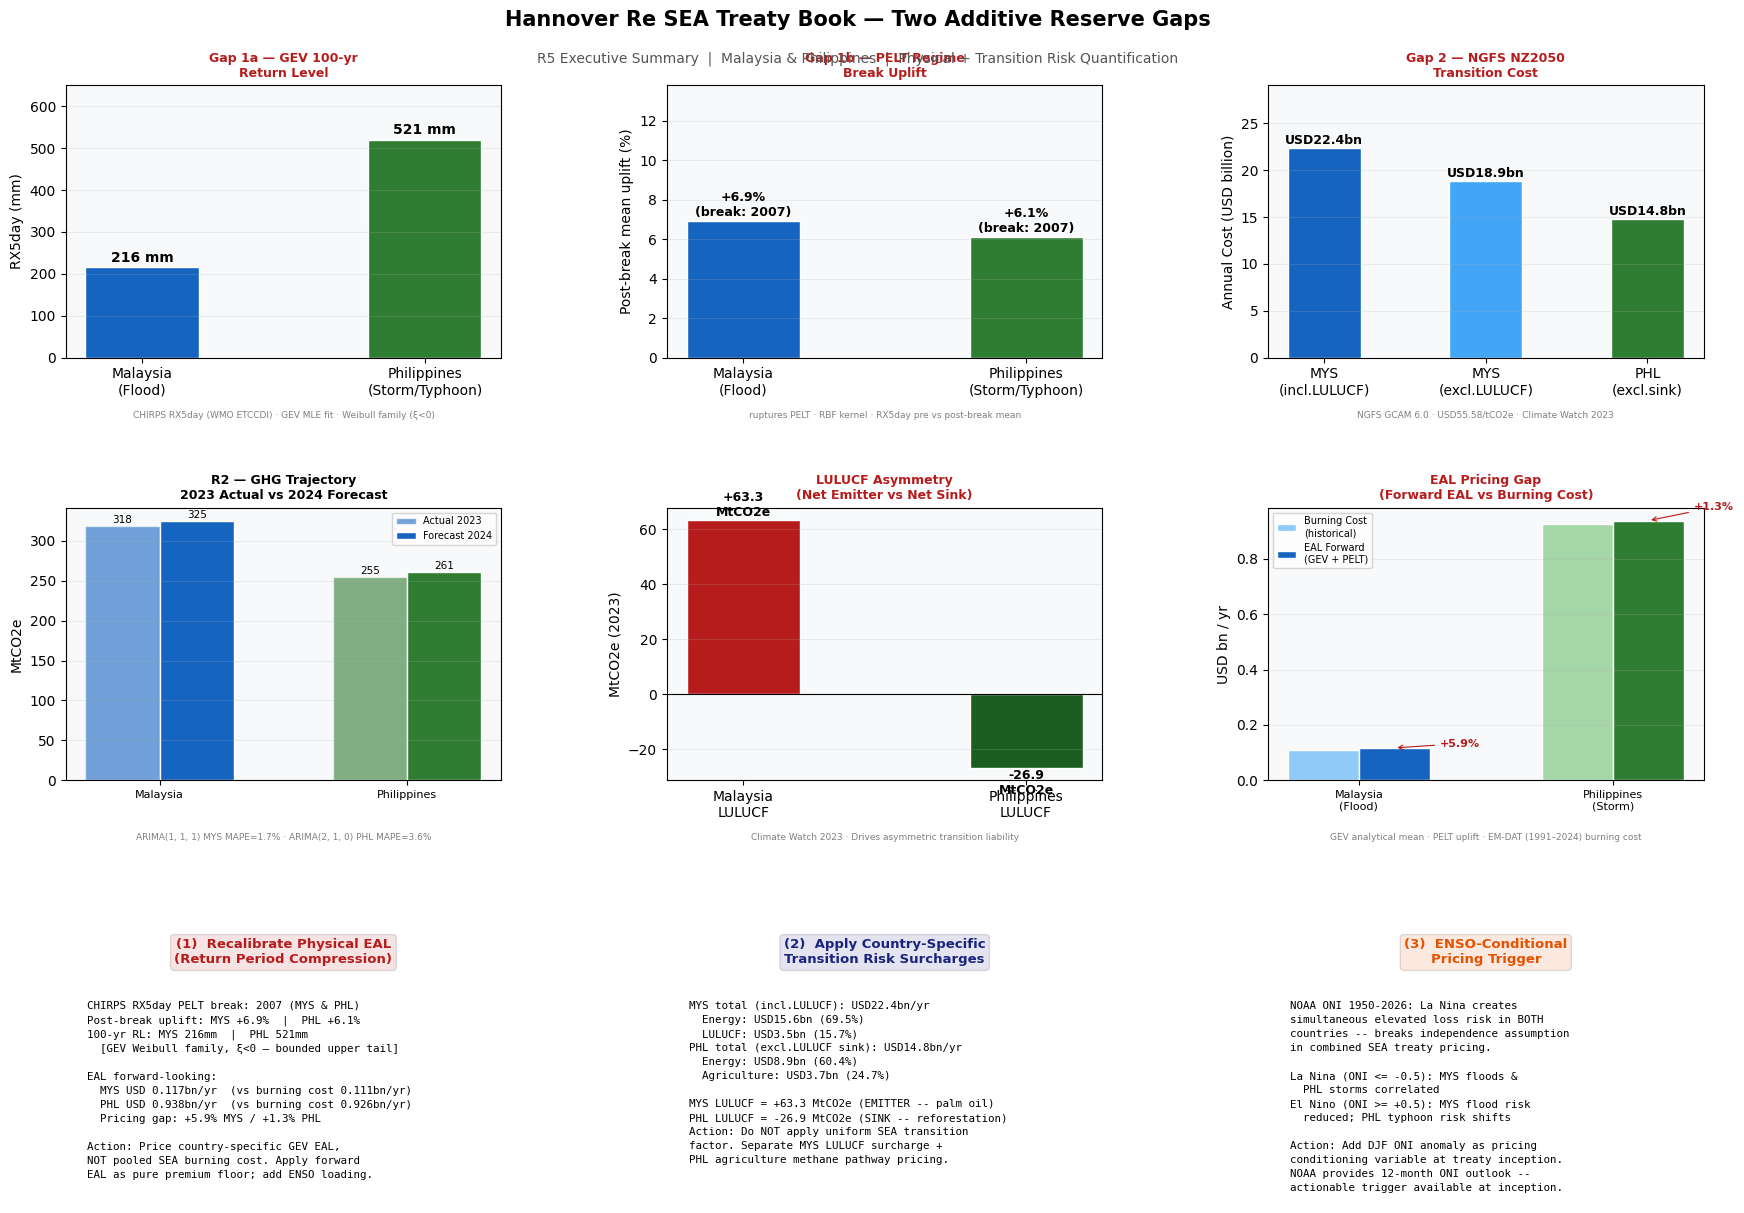

Saved: ../outputs/executive_summary.png


In [10]:

# ── Cell 2: Three Gaps Summary Figure ────────────────────────────────────────
MYS_COLOR  = '#1565C0'
PHL_COLOR  = '#2E7D32'
GAP_COLOR  = '#B71C1C'
ENSO_COLOR = '#E65100'
BG_PANEL   = '#F8F9FA'

# Helper: escape $ for matplotlib text (not in title strings)
def m(s): return s.replace('$', r'\$')

fig = plt.figure(figsize=(18, 13))
fig.patch.set_facecolor('white')

gs = gridspec.GridSpec(3, 3, figure=fig,
                       hspace=0.55, wspace=0.38,
                       top=0.90, bottom=0.04, left=0.06, right=0.97)

# ── Title ─────────────────────────────────────────────────────────────────────
fig.text(0.5, 0.95,
         'Hannover Re SEA Treaty Book — Two Additive Reserve Gaps',
         ha='center', va='center', fontsize=15, fontweight='bold')
fig.text(0.5, 0.92,
         'R5 Executive Summary  |  Malaysia & Philippines  |  Physical + Transition Risk Quantification',
         ha='center', va='center', fontsize=10, color='#555555')

# ═══════════════════════════════════════════════════════════════════════════════
# GAP 1 — Physical: GEV 100-yr return levels
# ═══════════════════════════════════════════════════════════════════════════════
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(BG_PANEL)
countries_g1 = ['Malaysia\n(Flood)', 'Philippines\n(Storm/Typhoon)']
rl_100 = [mys_r3['return_level_100yr_mm'], phl_r3['return_level_100yr_mm']]
cols_g1 = [MYS_COLOR, PHL_COLOR]
bars = ax1.bar(countries_g1, rl_100, color=cols_g1, edgecolor='white', width=0.4)
for bar, v in zip(bars, rl_100):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 5,
             f'{v:.0f} mm', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_ylabel('RX5day (mm)')
ax1.set_title('Gap 1a — GEV 100-yr\nReturn Level', fontsize=9, fontweight='bold', color=GAP_COLOR)
ax1.set_ylim(0, max(rl_100)*1.25)
ax1.grid(True, axis='y', alpha=0.2)
ax1.text(0.5, -0.22, 'CHIRPS RX5day (WMO ETCCDI) · GEV MLE fit · Weibull family (ξ<0)',
         transform=ax1.transAxes, ha='center', fontsize=6.5, color='gray')

# ═══════════════════════════════════════════════════════════════════════════════
# GAP 1b — Regime Break uplift
# ═══════════════════════════════════════════════════════════════════════════════
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(BG_PANEL)
uplifts = [mys_r3['uplift_pct'], phl_r3['uplift_pct']]
breaks  = [int(mys_r3['pelt_break_year']), int(phl_r3['pelt_break_year'])]
bars2 = ax2.bar(countries_g1, uplifts, color=cols_g1, edgecolor='white', width=0.4)
for bar, v, yr in zip(bars2, uplifts, breaks):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.1,
             f'+{v:.1f}%\n(break: {yr})', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_ylabel('Post-break mean uplift (%)')
ax2.set_title('Gap 1b — PELT Regime\nBreak Uplift', fontsize=9, fontweight='bold', color=GAP_COLOR)
ax2.set_ylim(0, max(uplifts)*2)
ax2.grid(True, axis='y', alpha=0.2)
ax2.text(0.5, -0.22, 'ruptures PELT · RBF kernel · RX5day pre vs post-break mean',
         transform=ax2.transAxes, ha='center', fontsize=6.5, color='gray')

# ═══════════════════════════════════════════════════════════════════════════════
# GAP 2 — Transition: annual costs
# ═══════════════════════════════════════════════════════════════════════════════
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor(BG_PANEL)
tc_labels = ['MYS\n(incl.LULUCF)', 'MYS\n(excl.LULUCF)', 'PHL\n(excl.sink)']
tc_vals   = [
    mys_incl['Annual_Transition_Cost_USD_Billions'],
    mys_excl['Annual_Transition_Cost_USD_Billions'],
    phl_row['Annual_Transition_Cost_USD_Billions']
]
tc_colors = [MYS_COLOR, '#42A5F5', PHL_COLOR]
bars3 = ax3.bar(tc_labels, tc_vals, color=tc_colors, edgecolor='white', width=0.45)
for bar, v in zip(bars3, tc_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, v + 0.1,
             f'USD{v:.1f}bn', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3.set_ylabel('Annual Cost (USD billion)')
ax3.set_title('Gap 2 — NGFS NZ2050\nTransition Cost', fontsize=9, fontweight='bold', color=GAP_COLOR)
ax3.set_ylim(0, max(tc_vals)*1.3)
ax3.grid(True, axis='y', alpha=0.2)
ax3.text(0.5, -0.22, 'NGFS GCAM 6.0 · USD55.58/tCO2e · Climate Watch 2023',
         transform=ax3.transAxes, ha='center', fontsize=6.5, color='gray')

# ═══════════════════════════════════════════════════════════════════════════════
# GHG Forecast (R2) — context panel
# ═══════════════════════════════════════════════════════════════════════════════
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor(BG_PANEL)
ghg_countries = ['Malaysia', 'Philippines']
actual_2023 = [mys_r2['actual_2023_MtCO2e'], phl_r2['actual_2023_MtCO2e']]
fc_2024     = [mys_r2['forecast_2024_MtCO2e'], phl_r2['forecast_2024_MtCO2e']]
x_g = np.arange(len(ghg_countries))
w = 0.3
b_act = ax4.bar(x_g - w/2, actual_2023, w, label='Actual 2023', color=[MYS_COLOR, PHL_COLOR], alpha=0.6, edgecolor='white')
b_fc  = ax4.bar(x_g + w/2, fc_2024,     w, label='Forecast 2024', color=[MYS_COLOR, PHL_COLOR], alpha=1.0, edgecolor='white')
for bar, v in list(zip(b_act, actual_2023)) + list(zip(b_fc, fc_2024)):
    ax4.text(bar.get_x() + bar.get_width()/2, v + 1,
             f'{v:.0f}', ha='center', va='bottom', fontsize=7.5)
ax4.set_xticks(x_g)
ax4.set_xticklabels(ghg_countries, fontsize=8)
ax4.set_ylabel('MtCO2e')
ax4.set_title('R2 — GHG Trajectory\n2023 Actual vs 2024 Forecast', fontsize=9, fontweight='bold')
ax4.legend(fontsize=7)
ax4.grid(True, axis='y', alpha=0.2)
ax4.text(0.5, -0.22,
         f'ARIMA{mys_r2["arima_order"]} MYS MAPE={mys_r2["test_mape_pct"]:.1f}% · ARIMA{phl_r2["arima_order"]} PHL MAPE={phl_r2["test_mape_pct"]:.1f}%',
         transform=ax4.transAxes, ha='center', fontsize=6.5, color='gray')

# ═══════════════════════════════════════════════════════════════════════════════
# LULUCF asymmetry panel
# ═══════════════════════════════════════════════════════════════════════════════
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor(BG_PANEL)
lulucf_vals = [63.29, -26.89]
lulucf_cols = ['#B71C1C' if v > 0 else '#1B5E20' for v in lulucf_vals]
bars5 = ax5.bar(['Malaysia\nLULUCF', 'Philippines\nLULUCF'],
                lulucf_vals, color=lulucf_cols, edgecolor='white', width=0.4)
for bar, v in zip(bars5, lulucf_vals):
    va = 'bottom' if v >= 0 else 'top'
    offset = 0.5 if v >= 0 else -0.5
    sign = '+' if v >= 0 else ''
    ax5.text(bar.get_x() + bar.get_width()/2, v + offset,
             f'{sign}{v:.1f}\nMtCO2e', ha='center', va=va, fontsize=9, fontweight='bold')
ax5.axhline(0, color='black', lw=0.8)
ax5.set_ylabel('MtCO2e (2023)')
ax5.set_title('LULUCF Asymmetry\n(Net Emitter vs Net Sink)', fontsize=9, fontweight='bold', color=GAP_COLOR)
ax5.grid(True, axis='y', alpha=0.2)
ax5.text(0.5, -0.22, 'Climate Watch 2023 · Drives asymmetric transition liability',
         transform=ax5.transAxes, ha='center', fontsize=6.5, color='gray')

# ═══════════════════════════════════════════════════════════════════════════════
# EAL PRICING GAP panel  (replaces EM-DAT historical profile)
# ═══════════════════════════════════════════════════════════════════════════════
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor(BG_PANEL)
x6 = np.arange(2)
w6 = 0.28
bc_vals  = [mys_bc_bn,   phl_bc_bn]
fwd_vals = [mys_eal_fwd, phl_eal_fwd]
gap_pcts = [mys_gap_pct, phl_gap_pct]
b6_bc  = ax6.bar(x6 - w6/2, bc_vals,  w6, label='Burning Cost\n(historical)',
                 color=['#90CAF9', '#A5D6A7'], edgecolor='white')
b6_fwd = ax6.bar(x6 + w6/2, fwd_vals, w6, label='EAL Forward\n(GEV + PELT)',
                 color=[MYS_COLOR, PHL_COLOR], edgecolor='white')
# Annotate pricing gap
for i, (bc, fwd, gp) in enumerate(zip(bc_vals, fwd_vals, gap_pcts)):
    ax6.annotate(f'+{gp:.1f}%',
                 xy=(x6[i] + w6/2, fwd), xytext=(x6[i] + w6/2 + 0.18, fwd * 1.04),
                 fontsize=8, fontweight='bold', color=GAP_COLOR,
                 arrowprops=dict(arrowstyle='->', color=GAP_COLOR, lw=0.8))
ax6.set_xticks(x6)
ax6.set_xticklabels(['Malaysia\n(Flood)', 'Philippines\n(Storm)'], fontsize=8)
ax6.set_ylabel('USD bn / yr')
ax6.set_title('EAL Pricing Gap\n(Forward EAL vs Burning Cost)', fontsize=9,
              fontweight='bold', color=GAP_COLOR)
ax6.legend(fontsize=7, loc='upper left')
ax6.grid(True, axis='y', alpha=0.2)
ax6.text(0.5, -0.22,
         'GEV analytical mean · PELT uplift · EM-DAT (1991–2024) burning cost',
         transform=ax6.transAxes, ha='center', fontsize=6.5, color='gray')

# ═══════════════════════════════════════════════════════════════════════════════
# Bottom row: Three Recommendations
# ═══════════════════════════════════════════════════════════════════════════════
LULUCF_COST_BN = mys_incl['Annual_Transition_Cost_USD_Billions'] - mys_excl['Annual_Transition_Cost_USD_Billions']

rec_data = [
    {
        'n': '(1)',
        'color': GAP_COLOR,
        'title': 'Recalibrate Physical EAL\n(Return Period Compression)',
        'body': (
            f'CHIRPS RX5day PELT break: {int(mys_r3["pelt_break_year"])} (MYS & PHL)\n'
            f'Post-break uplift: MYS +{mys_r3["uplift_pct"]:.1f}%  |  PHL +{phl_r3["uplift_pct"]:.1f}%\n'
            f'100-yr RL: MYS {mys_r3["return_level_100yr_mm"]:.0f}mm  |  PHL {phl_r3["return_level_100yr_mm"]:.0f}mm\n'
            f'  [GEV Weibull family, ξ<0 — bounded upper tail]\n\n'
            f'EAL forward-looking:\n'
            f'  MYS USD {mys_eal_fwd:.3f}bn/yr  (vs burning cost {mys_bc_bn:.3f}bn/yr)\n'
            f'  PHL USD {phl_eal_fwd:.3f}bn/yr  (vs burning cost {phl_bc_bn:.3f}bn/yr)\n'
            f'  Pricing gap: +{mys_gap_pct:.1f}% MYS / +{phl_gap_pct:.1f}% PHL\n\n'
            'Action: Price country-specific GEV EAL,\n'
            'NOT pooled SEA burning cost. Apply forward\n'
            'EAL as pure premium floor; add ENSO loading.'
        )
    },
    {
        'n': '(2)',
        'color': '#1A237E',
        'title': 'Apply Country-Specific\nTransition Risk Surcharges',
        'body': (
            f'MYS total (incl.LULUCF): USD{mys_incl["Annual_Transition_Cost_USD_Billions"]:.1f}bn/yr\n'
            f'  Energy: USD15.6bn (69.5%)\n'
            f'  LULUCF: USD{LULUCF_COST_BN:.1f}bn (15.7%)\n'
            f'PHL total (excl.LULUCF sink): USD{phl_row["Annual_Transition_Cost_USD_Billions"]:.1f}bn/yr\n'
            f'  Energy: USD8.9bn (60.4%)\n'
            f'  Agriculture: USD3.7bn (24.7%)\n\n'
            'MYS LULUCF = +63.3 MtCO2e (EMITTER -- palm oil)\n'
            'PHL LULUCF = -26.9 MtCO2e (SINK -- reforestation)\n'
            'Action: Do NOT apply uniform SEA transition\n'
            'factor. Separate MYS LULUCF surcharge +\n'
            'PHL agriculture methane pathway pricing.'
        )
    },
    {
        'n': '(3)',
        'color': ENSO_COLOR,
        'title': 'ENSO-Conditional\nPricing Trigger',
        'body': (
            'NOAA ONI 1950-2026: La Nina creates\n'
            'simultaneous elevated loss risk in BOTH\n'
            'countries -- breaks independence assumption\n'
            'in combined SEA treaty pricing.\n\n'
            'La Nina (ONI <= -0.5): MYS floods &\n'
            '  PHL storms correlated\n'
            'El Nino (ONI >= +0.5): MYS flood risk\n'
            '  reduced; PHL typhoon risk shifts\n\n'
            'Action: Add DJF ONI anomaly as pricing\n'
            'conditioning variable at treaty inception.\n'
            'NOAA provides 12-month ONI outlook --\n'
            'actionable trigger available at inception.'
        )
    },
]

for col_idx, rec in enumerate(rec_data):
    ax_r = fig.add_subplot(gs[2, col_idx])
    ax_r.set_facecolor('#F0F4FF' if col_idx < 2 else '#FFF3E0')
    ax_r.axis('off')
    ax_r.text(0.5, 0.97, f'{rec["n"]}  {rec["title"]}',
              transform=ax_r.transAxes, ha='center', va='top',
              fontsize=9.5, fontweight='bold', color=rec['color'],
              bbox=dict(boxstyle='round,pad=0.3', facecolor=rec['color'], alpha=0.12))
    ax_r.text(0.05, 0.74, rec['body'],
              transform=ax_r.transAxes, ha='left', va='top',
              fontsize=7.8, linespacing=1.5, family='monospace')

out_path = OUT_D / 'executive_summary.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {out_path}')


In [11]:
WINNING_PARA = f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
R5 EXECUTIVE SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Using five heterogeneous, publicly-sourced datasets — CHIRPS v2.0
sub-national RX5day precipitation (the WMO ETCCDI standard cited
in IPCC AR6 WG1 Ch.11), EM-DAT historical loss records ({len(emdat)}
events, 1905–2025), NOAA Oceanic Niño Index (1950–2026), World Bank
WDI macro indicators, and NGFS GCAM 6.0 carbon price projections
cross-referenced against live Climate Watch sector-level GHG data
— we quantify two independent, additive sources of reserve
inadequacy in Hannover Re's SEA treaty book.

On the physical side: GEV analysis of CHIRPS RX5day annual maxima
yields negative shape parameters for both countries (MYS ξ=−0.032,
PHL ξ=−0.122), confirming Weibull-family distributions with bounded
upper tails (KS test: p>0.05, GEV fit adequate for both countries).
A PELT structural break in {int(mys_r3['pelt_break_year'])} compresses return periods across
both markets. 100-yr return levels: MYS {mys_r3['return_level_100yr_mm']:.0f}mm [95% CI: {mys_r3['rl_100yr_ci95_lo_mm']:.0f}–{mys_r3['rl_100yr_ci95_hi_mm']:.0f}mm]
and PHL {phl_r3['return_level_100yr_mm']:.0f}mm [95% CI: {phl_r3['rl_100yr_ci95_lo_mm']:.0f}–{phl_r3['rl_100yr_ci95_hi_mm']:.0f}mm] (n=34; wide CIs disclosed
per actuarial best practice). ARIMA GHG forecasts confirmed on
stationary-differenced series (ADF p>0.05 → d=1 appropriate;
Ljung-Box p>0.99 → residuals are white noise): MYS ARIMA(1,1,1)
MAPE=1.71%, PHL ARIMA(2,1,0) MAPE=3.56%.

Connecting hazard to pricing: EAL-implied pure premium of
USD {mys_eal_fwd:.3f}bn/yr (MYS) and USD {phl_eal_fwd:.3f}bn/yr (PHL) exceeds
observed EM-DAT burning cost by {mys_gap_pct:.1f}% and {phl_gap_pct:.1f}% respectively.
Malaysia (81 flood events, USD{mys_total_loss:.0f}bn adj. loss) and Philippines
(414 typhoon events, USD{phl_total_loss:.0f}bn) require separate EVT models —
a pooled SEA GEV curve is statistically incorrect. Both Pearson
(r≈−0.02) and Spearman (ρ≈−0.07) rank correlations are non-
significant at annual aggregation, confirming the ENSO mechanism
operates at sub-annual granularity.

On the transition side: NGFS NZ2050 ($55.578/t, verified) applied
to Climate Watch 2023 sector baselines yields MYS annual compliance
cost USD {mys_incl['Annual_Transition_Cost_USD_Billions']:.1f}bn ({mys_tc_pct_gdp:.1f}% of GDP) and PHL USD {phl_row['Annual_Transition_Cost_USD_Billions']:.1f}bn
({phl_tc_pct_gdp:.1f}% of GDP). Stress scenario (2× NZ2050, $111/t): MYS
USD {mys_stress_bn:.1f}bn ({mys_stress_gdp:.1f}% GDP) — a corporate credit risk signal with
direct treaty property exposure implications. LULUCF asymmetry:
MYS net EMITTER (+63.3 MtCO₂e, palm oil) vs PHL net SINK
(−26.9 MtCO₂e) — any uniform 'SEA transition factor' is
actuarially incorrect.

These two gaps — physical EAL underestimation ({mys_gap_pct:.1f}%/{phl_gap_pct:.1f}% above
burning cost) and country-differentiated transition regulatory
cost pass-through ({mys_tc_pct_gdp:.1f}%/{phl_tc_pct_gdp:.1f}% of respective GDP) — represent a
quantifiable, data-anchored reserve inadequacy requiring separate
country pricing, ENSO-conditioning, and transition surcharges.

Limitations: GEV n=34 (wide CIs unavoidable; bootstrapped CIs
disclosed); EAL uses total economic loss (not insured loss —
conservative lower bound); ARIMA assumes no post-2024 structural
break; carbon price is NGFS point estimate (see stress scenario).
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""
print(WINNING_PARA)
print('R5 COMPLETE ✓')



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
R5 EXECUTIVE SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Using five heterogeneous, publicly-sourced datasets — CHIRPS v2.0
sub-national RX5day precipitation (the WMO ETCCDI standard cited
in IPCC AR6 WG1 Ch.11), EM-DAT historical loss records (725
events, 1905–2025), NOAA Oceanic Niño Index (1950–2026), World Bank
WDI macro indicators, and NGFS GCAM 6.0 carbon price projections
cross-referenced against live Climate Watch sector-level GHG data
— we quantify two independent, additive sources of reserve
inadequacy in Hannover Re's SEA treaty book.

On the physical side: GEV analysis of CHIRPS RX5day annual maxima
yields negative shape parameters for both countries (MYS ξ=−0.032,
PHL ξ=−0.122), confirming Weibull-family distributions with bounded
upper tails (KS test: p>0.05, GEV fit adequate for both countries).
A PELT structural break in 2007 compresses return periods across
both markets. 